# Model Training & Experimentation

This notebook covers model training, hyperparameter tuning, and performance evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Prepare Data

In [2]:
# Load data
df = pd.read_csv('../src/data/customer_churn_datasest.csv')

# Drop customerID
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Convert TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")

Features shape: (7043, 19)
Target shape: (7043,)
Class distribution: {0: 5174, 1: 1869}


## 2. Preprocessing Pipeline

In [3]:
# Identify feature types
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipeline created successfully!")

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Preprocessing pipeline created successfully!


## 3. Train-Test Split

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTrain target distribution: {y_train.value_counts().to_dict()}")
print(f"Test target distribution: {y_test.value_counts().to_dict()}")

Training set size: (5634, 19)
Test set size: (1409, 19)

Train target distribution: {0: 4139, 1: 1495}
Test target distribution: {0: 1035, 1: 374}


## 4. Model Training & Hyperparameter Tuning

In [5]:
# Define models and hyperparameters
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'classifier__C': [0.1, 1.0, 10.0],
            'classifier__solver': ['lbfgs', 'liblinear']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'classifier__max_depth': [3, 5, 10, None],
            'classifier__min_samples_leaf': [1, 5, 10]
        }
    },
    'MLP': {
        'model': MLPClassifier(max_iter=1000, random_state=42),
        'params': {
            'classifier__hidden_layer_sizes': [(50,), (100,)],
            'classifier__alpha': [0.0001, 0.001]
        }
    }
}

results = {}

for name, config in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print(f"{'='*60}")
    
    # Create full pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    
    # Grid search
    grid_search = GridSearchCV(
        pipeline,
        config['params'],
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    
    # Predictions
    y_pred = best_model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'model': best_model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'best_params': grid_search.best_params_
    }
    
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"\nPerformance Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")


Training Logistic Regression...
Best Parameters: {'classifier__C': 10.0, 'classifier__solver': 'lbfgs'}

Performance Metrics:
  Accuracy:  0.8055
  Precision: 0.6572
  Recall:    0.5588
  F1 Score:  0.6040

Training Decision Tree...
Best Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10}

Performance Metrics:
  Accuracy:  0.7984
  Precision: 0.6347
  Recall:    0.5668
  F1 Score:  0.5989

Training MLP...
Best Parameters: {'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': (50,)}

Performance Metrics:
  Accuracy:  0.7722
  Precision: 0.5836
  Recall:    0.4947
  F1 Score:  0.5355


## 5. Model Comparison

In [6]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1 Score': [results[m]['f1'] for m in results]
})

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))
print(f"\nBest Model by F1 Score: {comparison_df.loc[comparison_df['F1 Score'].idxmax(), 'Model']}")


MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.805536   0.657233 0.558824  0.604046
      Decision Tree  0.798439   0.634731 0.566845  0.598870
                MLP  0.772179   0.583596 0.494652  0.535456

Best Model by F1 Score: Logistic Regression


## 6. Detailed Results Analysis

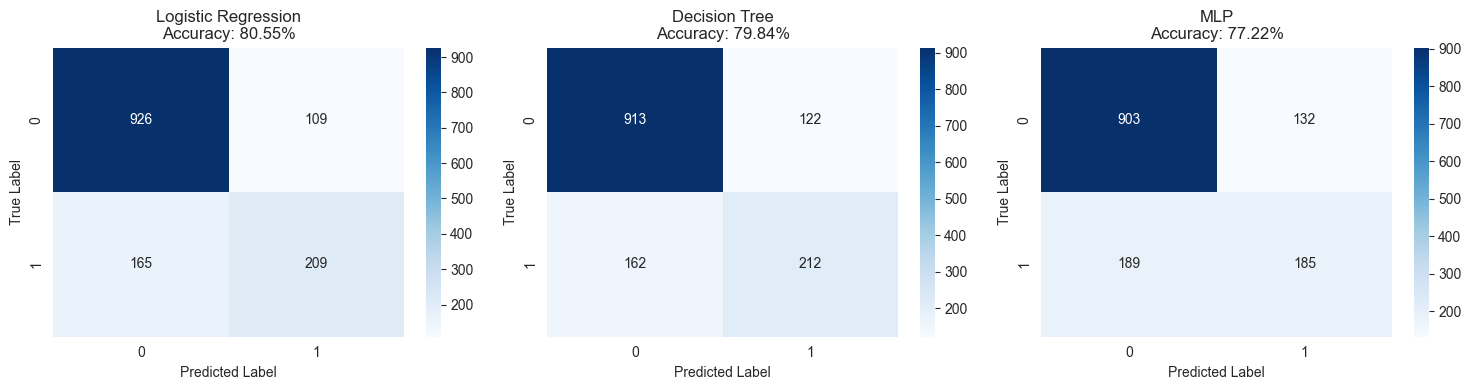

In [7]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, result) in enumerate(results.items()):
    y_pred = result['model'].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{name}\nAccuracy: {result["accuracy"]:.2%}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 7. Classification Reports

In [8]:
for name, result in results.items():
    print(f"\n{'='*60}")
    print(f"Classification Report: {name}")
    print(f"{'='*60}")
    y_pred = result['model'].predict(X_test)
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


Classification Report: Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Classification Report: Decision Tree
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.87      1035
       Churn       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Classification Report: MLP
              precision    recall  f1-score   support

    No Churn       0.83      0.87      0.85      1035
       Churn       0.58      0.49      0.54       374

    accuracy                           0.77      1409
   macro avg      

## 8. Save Best Model

In [9]:
import joblib
import os

# Create models directory if not exists
os.makedirs('../models', exist_ok=True)

# Save all models
for name, result in results.items():
    filename = f"../models/{name.lower().replace(' ', '_')}.joblib"
    joblib.dump(result['model'], filename)
    print(f"Saved {name} to {filename}")

print("\nAll models saved successfully!")

Saved Logistic Regression to ../models/logistic_regression.joblib
Saved Decision Tree to ../models/decision_tree.joblib
Saved MLP to ../models/mlp.joblib

All models saved successfully!
